In [1]:
from Model.rbm_classifier import RBM
from Model.config import Config
from Dataloader.dataset import get_dataloader, LetterImgDataset
from importlib import reload
import matplotlib.pyplot as plt
import torch

In [99]:
import Dataloader
reload(Dataloader)
import Dataloader.dataset as dataset
reload(dataset)

import Model.rbm_classifier
reload(Model.rbm_classifier)

import Model.config
reload(Model.config)

<module 'Model.config' from 'd:\\Programming\\LearnPy\\Letter Classification Restricted Boltzmann Machine\\Model\\config.py'>

In [101]:
img_dir_path = 'Dataset/train'
labels_csv_path = 'Dataset/train_labels.csv'

val_img_dir_path = 'Dataset/val'
val_labels_csv_path = 'Dataset/val_labels.csv'

cfg = Config()

dataloader, dataset = get_dataloader(img_dir_path, labels_csv_path, cfg.batch_size)
val_dataloader, val_dataset = get_dataloader(val_img_dir_path, val_labels_csv_path, cfg.batch_size)

q


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


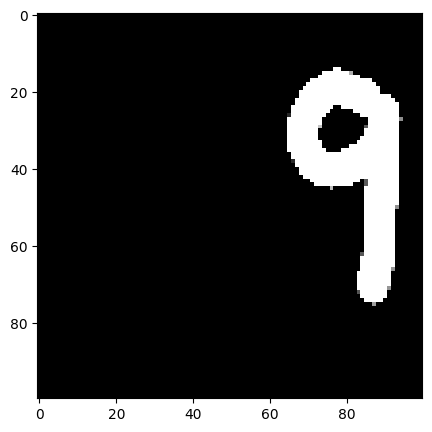

In [103]:
it = iter(dataloader)
img, label = next(it)

img = img.resize(cfg.batch_size, cfg.im_size, cfg.im_size)

print(val_dataset.one_hot_decode(label[0]))
plt.figure(figsize=(5, 5))
plt.imshow(img[0], cmap='gray')

In [40]:
print(label[0])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])


In [104]:
rbm = RBM(cfg.im_size * cfg.im_size, cfg.n_hidden, cfg.n_C, cfg.k)

In [9]:
val_data = list(iter(val_dataloader))

In [105]:
rbm.fit(dataloader, 10, val_data=val_dataloader)

w


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


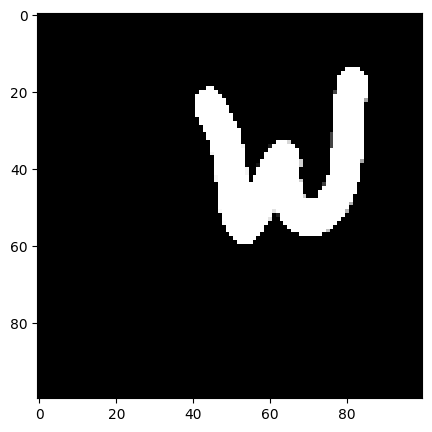

In [106]:
test_img_dir = 'Dataset/test'
test_labels_csv = 'Dataset/test_labels.csv'

test_dataloader, test_dataset = get_dataloader(test_img_dir, test_labels_csv, cfg.batch_size)
it = iter(test_dataloader)
img, label = next(it)


print(dataset.one_hot_decode(label[0]))
plt.figure(figsize=(5, 5))
plt.imshow(img[0].resize(cfg.im_size, cfg.im_size), cmap='gray')


In [ ]:
torch_dict = {
    'W': rbm.W,
    'U': rbm.U,
    'b_c': rbm.b_y,
    'b_h': rbm.b_h,
    'b_v': rbm.b_v
}

torch.save(torch_dict, 'rbm_model.pth')

In [84]:
dict = torch.load('rbm_model.pth')
rbm.W = dict['W']
rbm.U = dict['U']
rbm.b_y = dict['b_c']
rbm.b_h = dict['b_h']
rbm.b_v = dict['b_v']

C:\Users\HP\AppData\Local\Temp\ipykernel_25928\2637900945.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dict = torch.load('rbm_model.pth')


Predicted: w
label: w
tensor([True])


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


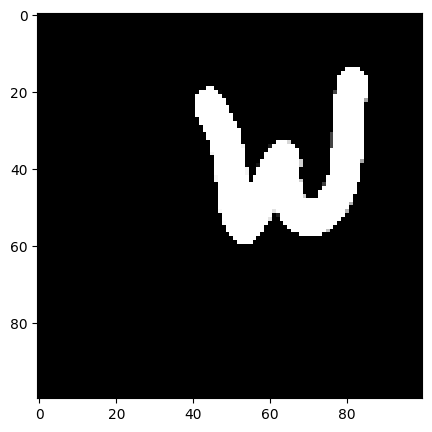

In [ ]:
_, predict = rbm.predict_y(img[0].unsqueeze(0))
lab = label

# print(dataset.one_hot_decode(lab))
one_hot_predicted = torch.zeros(cfg.n_C)
one_hot_predicted[predict[0]] = 1
print('Predicted:', dataset.one_hot_decode(one_hot_predicted))
print("label:", dataset.one_hot_decode(lab[0]))
plt.figure(figsize=(5, 5))
plt.imshow(img[0].resize(cfg.im_size, cfg.im_size), cmap='gray')
print(predict == torch.argmax(lab))
